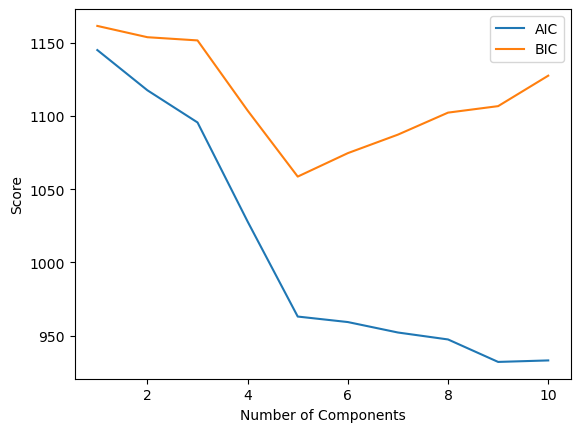

Log Likelihood: -2.262502621973241
Silhouette Score (GMM): 0.5536892843811245
Silhouette Score (KMeans): 0.5546571631111091


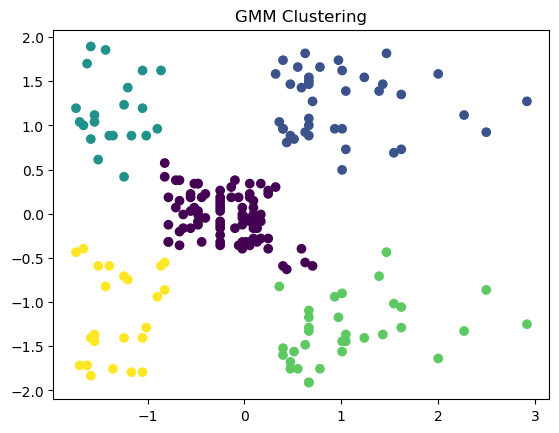

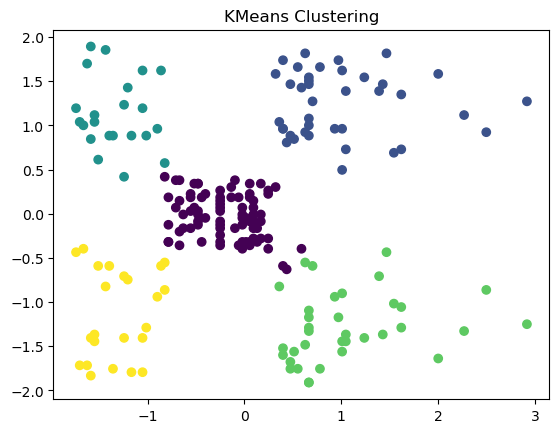

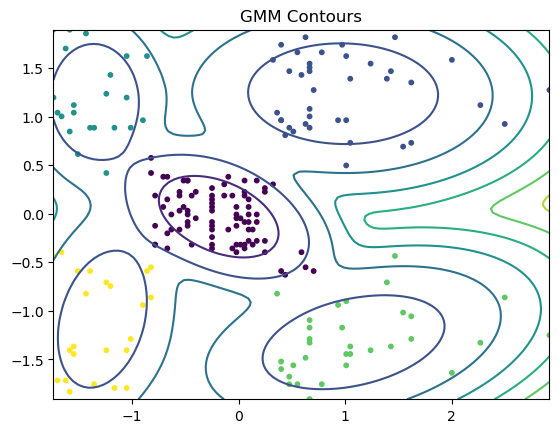

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("Mall_Customers.csv")

df = df.dropna()

X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

components = range(1, 11)
aic = []
bic = []

for n in components:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(X_scaled)
    aic.append(gmm.aic(X_scaled))
    bic.append(gmm.bic(X_scaled))

plt.figure()
plt.plot(components, aic, label="AIC")
plt.plot(components, bic, label="BIC")
plt.xlabel("Number of Components")
plt.ylabel("Score")
plt.legend()
plt.show()

gmm = GaussianMixture(n_components=5, random_state=42)
gmm.fit(X_scaled)

probs = gmm.predict_proba(X_scaled)
labels = np.argmax(probs, axis=1)

df["GMM_Cluster"] = labels

log_likelihood = gmm.score(X_scaled)
sil_score_gmm = silhouette_score(X_scaled, labels)

print("Log Likelihood:", log_likelihood)
print("Silhouette Score (GMM):", sil_score_gmm)

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

df["KMeans_Cluster"] = kmeans_labels

sil_score_kmeans = silhouette_score(X_scaled, kmeans_labels)
print("Silhouette Score (KMeans):", sil_score_kmeans)

plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis')
plt.title("GMM Clustering")
plt.show()

plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_labels, cmap='viridis')
plt.title("KMeans Clustering")
plt.show()

x = np.linspace(X_scaled[:, 0].min(), X_scaled[:, 0].max(), 100)
y = np.linspace(X_scaled[:, 1].min(), X_scaled[:, 1].max(), 100)
X_grid, Y_grid = np.meshgrid(x, y)
XX = np.array([X_grid.ravel(), Y_grid.ravel()]).T
Z = -gmm.score_samples(XX)
Z = Z.reshape(X_grid.shape)

plt.figure()
plt.contour(X_grid, Y_grid, Z)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, s=10)
plt.title("GMM Contours")
plt.show()